# Task 3.1 — TensorFlow/Keras Model (vs. PyTorch)
Build and train a TensorFlow/Keras neural network and compare it with the earlier PyTorch model.
To keep the comparison fair, both frameworks get the **same dataset, same preprocessing, same train/test split,
same architecture (9 → 16 → 8 → 1), same optimizer (Adam, lr=0.01), batch size (32) and epochs (50)**.
**Skill Set Go EduTech — AI/ML Internship, Week 3**

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
print("PyTorch:", torch.__version__)
# NOTE: TensorFlow is imported later, after the PyTorch model has finished training.
# Importing both at the top and training PyTorch afterwards caused a native thread-pool crash
# (segfault) in this environment, so the two frameworks are run sequentially.

PyTorch: 2.14.0+cu130


## 1. Shared data pipeline (identical for both frameworks)

In [2]:
df = pd.read_csv('data/titanic_cleaned.csv')
df_model = df.copy()
df_model['Sex'] = df_model['Sex'].map({'male': 0, 'female': 1})
df_model = pd.get_dummies(df_model, columns=['Embarked'], drop_first=True)

X = df_model.drop(columns=['Survived']).values.astype(np.float32)
y = df_model['Survived'].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)
input_dim = X_train.shape[1]
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (712, 9) | Test: (179, 9)


## 2. PyTorch model (same as Task 2.1)

In [3]:
torch.manual_seed(42)
pt_model = nn.Sequential(nn.Linear(input_dim, 16), nn.ReLU(), nn.Linear(16, 8), nn.ReLU(), nn.Linear(8, 1))
pt_loss_fn = nn.BCEWithLogitsLoss()
pt_opt = torch.optim.Adam(pt_model.parameters(), lr=0.01)

Xt, yt = torch.tensor(X_train), torch.tensor(y_train).unsqueeze(1)
loader = DataLoader(TensorDataset(Xt, yt), batch_size=32, shuffle=True)

pt_history = []
start = time.time()
for epoch in range(50):
    pt_model.train()
    total = 0.0
    for xb, yb in loader:
        pt_opt.zero_grad()
        loss = pt_loss_fn(pt_model(xb), yb)
        loss.backward()
        pt_opt.step()
        total += loss.item() * xb.size(0)
    pt_history.append(total / len(loader.dataset))
pt_time = time.time() - start

pt_model.eval()
with torch.no_grad():
    pt_preds = (torch.sigmoid(pt_model(torch.tensor(X_test))) >= 0.5).float().numpy().ravel()
pt_acc = accuracy_score(y_test, pt_preds)
pt_params = sum(p.numel() for p in pt_model.parameters())
print(f"PyTorch  | test acc: {pt_acc:.4f} | final train loss: {pt_history[-1]:.4f} | time: {pt_time:.2f}s | params: {pt_params}")

PyTorch  | test acc: 0.8101 | final train loss: 0.3500 | time: 3.06s | params: 305


## 3. TensorFlow/Keras model (same architecture)

In [4]:
import tensorflow as tf
from tensorflow import keras
print("TensorFlow:", tf.__version__)

keras.utils.set_random_seed(42)
tf_model = keras.Sequential([
    keras.layers.Input(shape=(input_dim,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1),   # raw logits, same as the PyTorch model
])
tf_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[keras.metrics.BinaryAccuracy(threshold=0.0, name='accuracy')],  # threshold on logits
)
tf_model.summary()

I0000 00:00:1791279559.137653     184 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1791279560.617564     184 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
start = time.time()
hist = tf_model.fit(X_train, y_train, batch_size=32, epochs=50, verbose=0)
tf_time = time.time() - start
tf_history = hist.history['loss']

tf_logits = tf_model.predict(X_test, verbose=0).ravel()
tf_preds = (tf_logits >= 0.0).astype(float)   # logit >= 0  <=>  sigmoid >= 0.5
tf_acc = accuracy_score(y_test, tf_preds)
tf_params = tf_model.count_params()
print(f"Keras    | test acc: {tf_acc:.4f} | final train loss: {tf_history[-1]:.4f} | time: {tf_time:.2f}s | params: {tf_params}")

Keras    | test acc: 0.7765 | final train loss: 0.3179 | time: 5.70s | params: 305


## 4. Side-by-side comparison

In [6]:
comparison = pd.DataFrame({
    'Metric': ['Test accuracy', 'Final train loss', 'Training time (s)', 'Trainable parameters'],
    'PyTorch': [round(pt_acc, 4), round(pt_history[-1], 4), round(pt_time, 2), pt_params],
    'TensorFlow/Keras': [round(tf_acc, 4), round(tf_history[-1], 4), round(tf_time, 2), tf_params],
})
comparison.to_csv('framework_comparison.csv', index=False)
comparison

,Metric,PyTorch,TensorFlow/Keras
0,Test accuracy,0.8101,0.7765
1,Final train loss,0.3500,0.3179
2,Training time (s),3.0600,5.7000
3,Trainable parameters,305.0000,305.0000


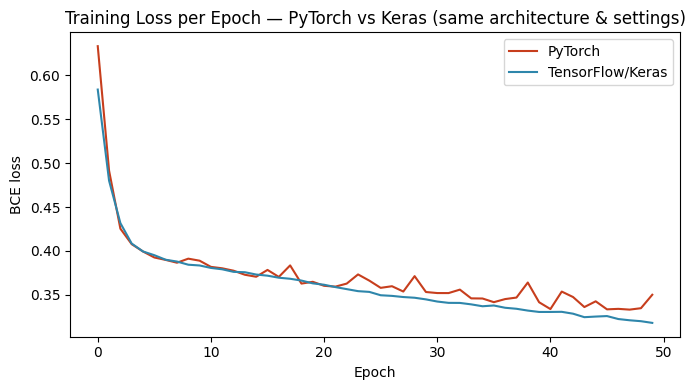

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(pt_history, label='PyTorch', color='#C73E1D')
plt.plot(tf_history, label='TensorFlow/Keras', color='#2E86AB')
plt.title('Training Loss per Epoch — PyTorch vs Keras (same architecture & settings)')
plt.xlabel('Epoch'); plt.ylabel('BCE loss'); plt.legend()
plt.tight_layout()
plt.savefig('pytorch_vs_keras_loss.png', dpi=100)
plt.show()

In [8]:
tf_model.save('titanic_keras_model.keras')
print("Saved: titanic_keras_model.keras")

Saved: titanic_keras_model.keras


## 5. Comparison notes

**Results (same data, split, architecture, optimizer, batch size, epochs, seed 42):**

| Metric | PyTorch | TensorFlow/Keras |
|---|---|---|
| Test accuracy | 0.8101 | 0.7765 |
| Final train loss | 0.3500 | 0.3179 |
| Training time | 3.06 s | 5.70 s |
| Trainable parameters | 305 | 305 |

**Performance:** PyTorch scored 3.4 points higher on test accuracy (about 6 more of the 179 test passengers classified correctly), while Keras reached a lower final *training* loss. That pattern (fits training data slightly tighter, generalizes slightly worse) is consistent with noise rather than a real framework difference: this is a single run with a single seed on a 179-row test set, so a gap this size is within normal run-to-run variation. I did not repeat the runs across seeds, so I can't claim either framework is better on this task. Likely contributors to the difference, though not isolated here, are the frameworks' different default weight initializers (Keras `Dense` uses Glorot-uniform; PyTorch `Linear` uses a Kaiming-style uniform) and slightly different Adam defaults (epsilon 1e-7 in Keras vs 1e-8 in PyTorch).

**Speed:** Keras was slower here (5.70 s vs 3.06 s). With a dataset this small, per-epoch fixed overhead in `model.fit` dominates, so this says little about speed at realistic scale.

**Developer experience:**
- *Training loop:* PyTorch needs an explicit loop (`zero_grad` → forward → loss → `backward` → `step`), which gives full control and makes it clear what is happening. Keras hides it behind `compile()` + `fit()`: about 15 fewer lines for the same result.
- *Loss/metrics:* in Keras, accuracy tracking is built into `compile()`. In PyTorch it is computed manually (here with scikit-learn).
- *Model definition:* nearly identical (`nn.Sequential` vs `keras.Sequential`); Keras requires declaring the input shape, PyTorch infers it from the first `Linear`.
- *Saving:* Keras saves the whole model in one call (`.keras` file); PyTorch conventionally saves only the weights (`state_dict`) and expects you to re-create the class.

**Takeaway:** for a small feed-forward network the two frameworks are interchangeable. Keras is faster to write; PyTorch is more explicit and easier to debug step by step. The accuracy gap seen here should not be read as evidence about either framework.